<a href="https://colab.research.google.com/github/kssuny/sjcu-python/blob/main/BAN230MidTerm_SunnyKim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First five rows:


,Species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,39.1,18.7,181,3750
1,Adelie,39.5,17.4,186,3800
2,Adelie,40.3,18.0,195,3250
3,Adelie,36.7,19.3,193,3450
4,Adelie,39.3,20.6,190,3650


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Species            342 non-null    object 
 1   bill_length_mm     342 non-null    float64
 2   bill_depth_mm      342 non-null    float64
 3   flipper_length_mm  342 non-null    int64  
 4   body_mass_g        342 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 13.5+ KB
None

Missing Values:
Species              0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

Missing Values After Cleaning:
Species              0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

Species Classes:
['Adelie' 'Chinstrap' 'Gentoo']

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.0

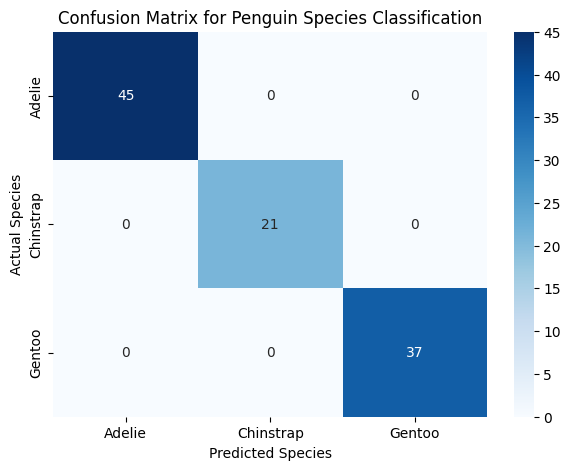

In [8]:

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load Dataset
penguins = pd.read_csv("penguins (2).xls")

print("First five rows:")
display(penguins.head())

# Explore and Clean Data
print("Dataset Information:")
print(penguins.info())

print("\nMissing Values:")
print(penguins.isnull().sum())

penguins_clean = penguins.dropna()

print("\nMissing Values After Cleaning:")
print(penguins_clean.isnull().sum())

# Select Features and Target Variable
X = penguins_clean[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
]

y = penguins_clean["Species"]

# Preprocess the Data
# Encode Target Variable and Standardize Features
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nSpecies Classes:")
print(label_encoder.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the Data
# 70% Training Data and 30% Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Build and Train the SVM Model
# Linear Kernel
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train, y_train)

# Predict and Evaluate the Model
y_pred = svm_model.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix for Penguin Species Classification")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()



The linear SVM model with all 103 samples predicted accurately with an accuracy of 1.00. From the classification report generated, Adelie, Chinstrap, and Gentoo penguins, with 45, 21, and 37 supports respectively, showed an accuracy of 1.00 in precision, recall, and F1-score measures. This implies that there was no prediction error for false positives or false negatives on the test samples of all species.

From the confusion matrix. All 45 of Adelie species of penguin was accurately identified as an Adelie, in all 21 cases, the Chinstrap penguin species was accurately identified as Chinstrap, and in all 37 cases, the Gentoo penguin was accurately identified as Gentoo.

In the three species considered here, Gentoo appears to be easier to identify, as it usually has a bigger body mass and flipper size compared to the other two species. As for Adelie and Chinstrap, their separation would be difficult because both species share similarities in terms of bills. However, the model was capable of classifying these birds successfully based on the physical measurements considered in this analysis.

It needs to be noted that perfect accuracy is not always desirable, despite being highly accurate. In particular, having an excellent result in just one train-test split does not ensure that the model will be as accurate when used for predicting new data. High performance can be a result of strong penguin data separability and balanced classes generated using stratified sampling.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19945 entries, 0 to 19944
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   master_id                          19945 non-null  object 
 1   order_channel                      19945 non-null  object 
 2   last_order_channel                 19945 non-null  object 
 3   first_order_date                   19945 non-null  object 
 4   last_order_date                    19945 non-null  object 
 5   last_order_date_online             19945 non-null  object 
 6   last_order_date_offline            19945 non-null  object 
 7   order_num_total_ever_online        19945 non-null  float64
 8   order_num_total_ever_offline       19945 non-null  float64
 9   customer_value_total_ever_offline  19945 non-null  float64
 10  customer_value_total_ever_online   19945 non-null  float64
 11  interested_in_categories_12        19945 non-null  obj

/tmp/ipykernel_2256/1910754011.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = rfm.groupby("Segment").agg({


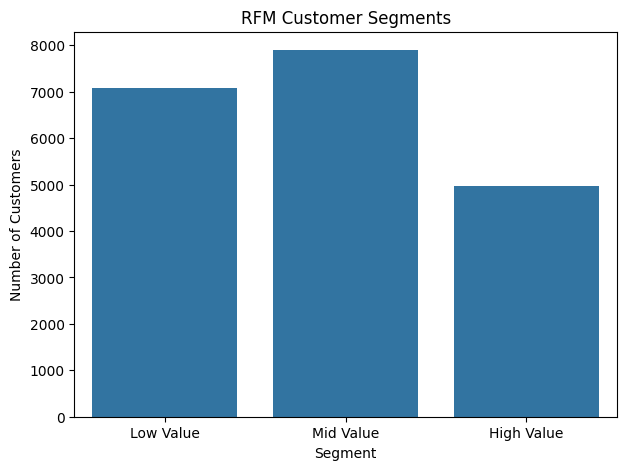

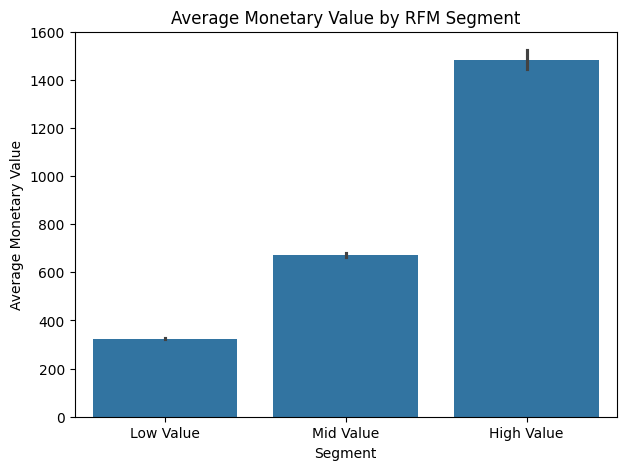

Explained Variance Ratio:
[0.60551053 0.3221109 ]


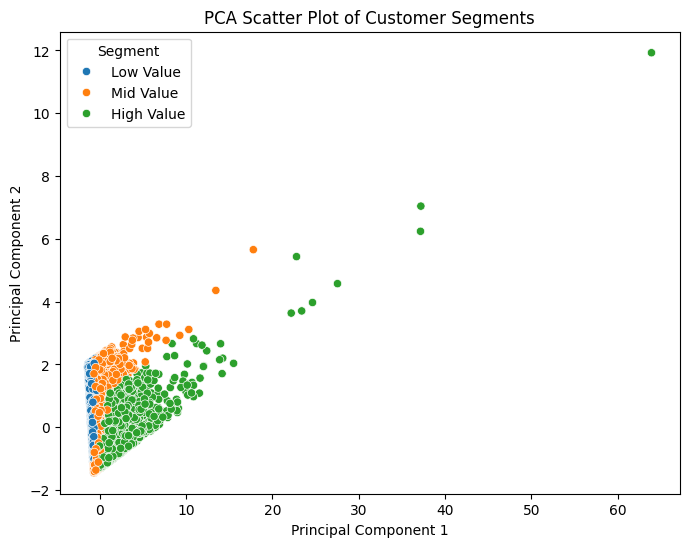

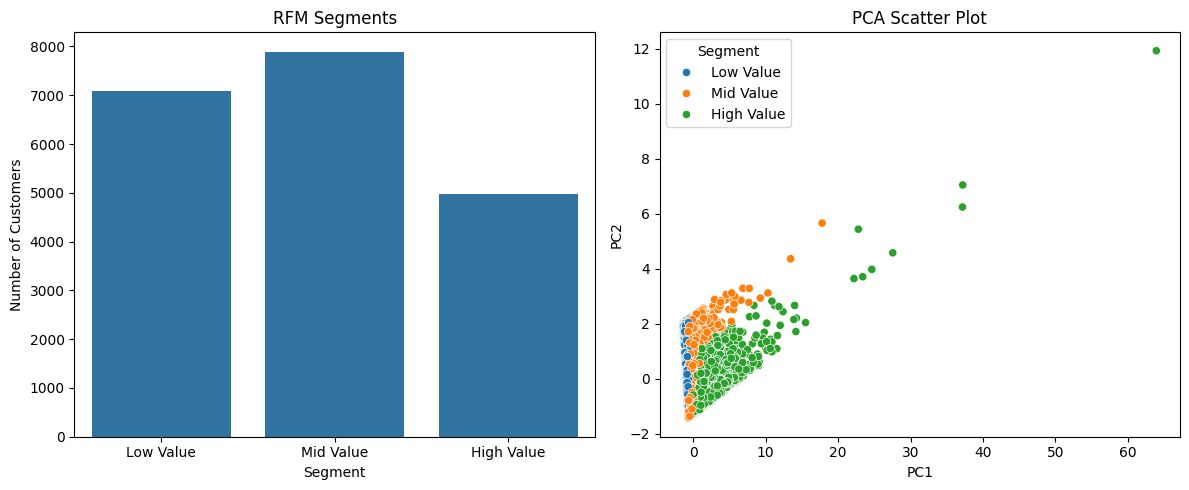

In [18]:
# Part II: Customer Segmentation using RFM and PCA

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("flo_data_20k.csv")

# Display first rows
df.head()

# Check data information
df.info()

# Check missing values
df.isnull().sum()

# Drop missing values
df = df.dropna()

# Confirm missing values
df.isnull().sum()

# Display columns
df.columns

# Convert date columns to datetime
df["first_order_date"] = pd.to_datetime(df["first_order_date"])
df["last_order_date"] = pd.to_datetime(df["last_order_date"])
df["last_order_date_online"] = pd.to_datetime(df["last_order_date_online"])
df["last_order_date_offline"] = pd.to_datetime(df["last_order_date_offline"])

# Create Total Order Number
df["TotalOrder"] = df["order_num_total_ever_online"] + df["order_num_total_ever_offline"]

# Create Total Amount
df["TotalAmount"] = df["customer_value_total_ever_online"] + df["customer_value_total_ever_offline"]

# Set snapshot date
snapshot_date = df["last_order_date"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("master_id").agg({
    "last_order_date": lambda x: (snapshot_date - x.max()).days,
    "TotalOrder": "sum",
    "TotalAmount": "sum"
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Display RFM table
rfm.head()

# Check RFM information
rfm.info()

# Create RFM scores
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])

# Combine RFM scores
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

# Create total RFM score
rfm["RFM_Total"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

# Create customer segments based on thirds (33%)
rfm["Segment"] = pd.qcut(
    rfm["RFM_Total"],
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

# Display first rows
rfm.head()

# Count segments
rfm["Segment"].value_counts()

# Segment summary
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).reset_index()

# Rename column
segment_summary = segment_summary.rename(columns={"CustomerID": "CustomerCount"})

# Display segment summary
segment_summary

# RFM segment visualization
plt.figure(figsize=(7, 5))
sns.countplot(x="Segment", data=rfm)
plt.title("RFM Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

# RFM Monetary by Segment
plt.figure(figsize=(7, 5))
sns.barplot(x="Segment", y="Monetary", data=rfm)
plt.title("Average Monetary Value by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Average Monetary Value")
plt.show()

# Prepare data for PCA
X = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize RFM values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(data=pca_result, columns=["PC1", "PC2"])

# Add segment column
pca_df["Segment"] = rfm["Segment"]

# Display PCA dataframe
pca_df.head()

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# PCA scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Segment", data=pca_df)
plt.title("PCA Scatter Plot of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Side-by-side visualization

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x="Segment", data=rfm)
plt.title("RFM Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.subplot(1, 2, 2)
sns.scatterplot(x="PC1", y="PC2", hue="Segment", data=pca_df)
plt.title("PCA Scatter Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()


From both RFM analysis and PCA were performed on the customers' transactions data set to assess the efficiency of both approaches in performing customer segmentation.

As a result of the RFM analysis, customers were separated into High Value, Mid Value, and Low Value segments depending on the Recency, Frequency, and Monetary values. As for the customer distribution among these segments, Mid Value customers turned out to make up the largest group, and the High Value ones comprised the smallest part of the customer base. Yet, the Average Monetary Value graph indicated that High Value customers produced the largest amount of money, and the value of their purchases was nearly equal to 1,500; Low Value clients made purchases at the sum of 330 on average. Thus, a relatively small number of people generates most revenue for the company. One benefit of using this approach is that the results are easily interpreted and can be used to develop various decisions related to marketing strategies. A drawback includes the use of only three variables in the analysis.

RFM analysis was done on the RFM data using PCA where two principal components were obtained, the first having 60.55% variance and the second one accounting for 32.21% variance, giving a total variance of 92.76%. Therefore, a lot of information in the initial data was retained. It is evident from the scatter diagram that a clear pattern exists in the customers as well as outliers. However, there is an overlap between High Value, Mid Value, and Low Value customers.

It is concluded that RFM analysis is suitable for business applications. While PCA is helpful in pattern recognition, it does not offer customer segmentations which make sense from a business point of view. Businesses find it easy to apply such customer segments in their activities in order to enhance revenue.